In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

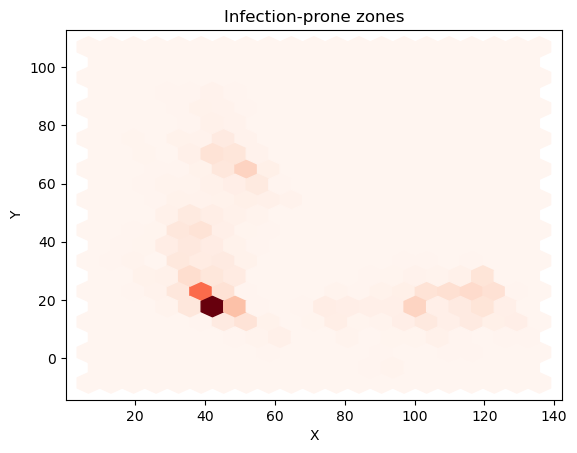

In [54]:
logs = pd.read_csv("contact logs.csv")
#sns.scatterplot(data=logs, x='x1', y='y1')
plt.hexbin(logs['x1'], logs['y1'], gridsize=20, cmap='Reds')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Infection-prone zones')
plt.show()

In [43]:
logs

,timestamp,agent1_id,agent1_type,x1,y1,agent2_id,agent2_type,x2,y2,contact_x,contact_y,distance_ft
0,Thu Jul 18 07:23:43 CEST 2024,57587,nurse,51.397065,28.571499,62036,nurse,44.247312,32.884537,47.822189,30.728018,2.606806
1,Thu Jul 18 08:22:25 CEST 2024,57587,nurse,37.369784,27.352527,57599,nurse,35.012158,31.384526,36.190971,29.368527,1.458169
2,Thu Jul 18 08:29:14 CEST 2024,57587,nurse,115.379208,23.979607,62042,pharmacist,121.298679,21.900499,118.338944,22.940053,1.958706
3,Thu Jul 18 08:34:35 CEST 2024,57587,nurse,43.172827,20.043620,62043,doctor,45.112435,18.882719,44.142631,19.463169,0.705711
4,Thu Jul 18 09:11:30 CEST 2024,57587,nurse,52.000920,14.939601,62045,nurse,45.917042,16.039908,48.958981,15.489754,1.930170
...,...,...,...,...,...,...,...,...,...,...,...,...
20177,Tue Oct 15 21:38:56 CEST 2024,62046,physiotherapist,36.974800,49.739139,62023,nurse,36.272589,46.071216,36.623695,47.905177,1.165904
20178,Tue Oct 15 23:08:39 CEST 2024,62031,nurse,41.635574,20.242146,62020,doctor,41.833036,20.658624,41.734305,20.450385,0.143896
20179,Tue Oct 15 23:17:29 CEST 2024,62030,doctor,55.262600,8.987581,57599,nurse,47.885857,15.445696,51.574228,12.216638,3.060843
20180,Tue Oct 15 23:29:52 CEST 2024,62046,physiotherapist,59.205647,11.272015,62037,nurse,50.617831,13.976440,54.911739,12.624227,2.810875


In [59]:
moves = pd.read_excel("Hospital Data.xlsx")
moves.groupby(by='tagId')[['x1', 'y1']].std().to_csv('moves std.csv')

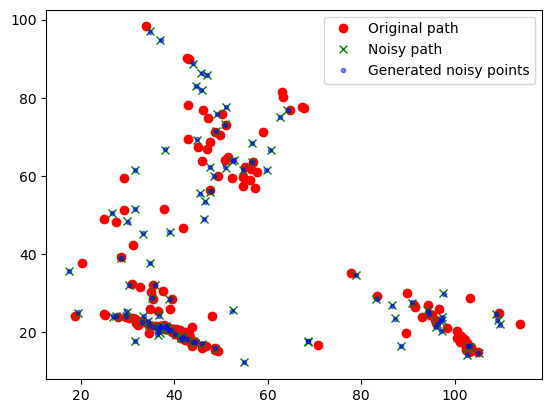

In [46]:
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt

points = moves[['x1', 'y1']].to_numpy()
x, y = points[:, 0], points[:, 1]

# Create spline (smooth path)
tck, u = splprep([x, y], s=0)
u_new = np.linspace(0, 1, 100)
x_new, y_new = splev(u_new, tck)
plt.plot(x, y, 'ro', label='Original path')
plt.plot(x_new, y_new, 'gx', label='Noisy path')

# Add noise to interpolated points
noise_std = 0.1
x_noisy = x_new + np.random.normal(0, noise_std, len(x_new))
y_noisy = y_new + np.random.normal(0, noise_std, len(y_new))

generated_points = np.column_stack((x_noisy, y_noisy))

# Plot original and generated points
#plt.plot(x, y, 'ro-', label='Original path')
plt.plot(generated_points[:, 0], generated_points[:, 1], 'b.', alpha=0.5, label='Generated noisy points')
plt.legend()
plt.show()


In [2]:
moves = pd.read_excel("moves.xlsx")

C:\Users\mohamed.abourraja\AppData\Local\anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [3]:
moves['day'] = moves['time'].dt.day - 16

In [4]:
moves

,tag id,time,color,type,x1,y1,day
0,57586,2024-07-16 06:25:37,yellow,nurse desk,34.730938,21.880232,0
1,62024,2024-07-16 06:25:37,red,doctor,45.844396,17.747976,0
2,57590,2024-07-16 06:25:37,yellow,nurse desk,40.839687,20.490737,0
3,62026,2024-07-16 06:25:37,blue,head nurse,36.417691,21.457325,0
4,57589,2024-07-16 06:25:38,yellow,nurse desk,53.255370,17.009790,0
...,...,...,...,...,...,...,...
104920,57587,2024-07-21 13:42:58,blue,nurse,105.794390,21.699554,5
104921,62036,2024-07-21 13:42:59,blue,nurse,42.093624,43.934343,5
104922,62023,2024-07-21 13:43:00,blue,nurse,34.402601,48.335818,5
104923,62041,2024-07-21 13:43:00,gray,cleaning staff,34.183364,35.446427,5


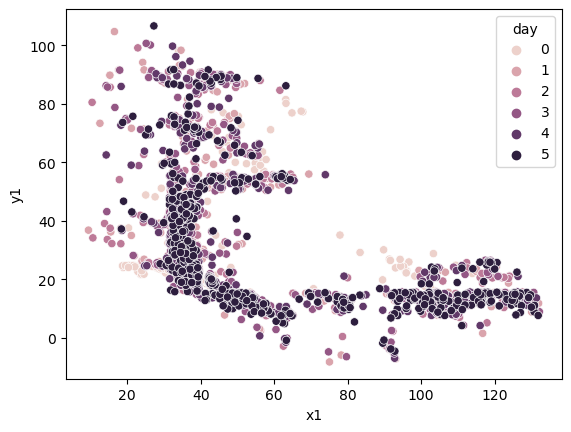

In [5]:
df = moves[moves['tag id'] == 57586]
sns.scatterplot(data=df, x='x1', y='y1', hue='day')
plt.show()

In [6]:
stats_dfs = []
new_moves_dfs = []
for agent, a_group in moves.groupby(by='tag id'):
    d_groups = a_group[a_group['day'] != 0].groupby(by='day')
    
    columns, data = zip(*[(f'x1_{day}', d_group['x1'].values) for day, d_group in d_groups])
    xs = pd.DataFrame(data=np.array(data).T, columns=columns)
    
    columns, data = zip(*[(f'y1_{day}', d_group['y1'].values) for day, d_group in d_groups])
    ys = pd.DataFrame(data=np.array(data).T, columns=columns)
    
    stats = pd.DataFrame(data=zip(*[[agent] * len(xs), range(0, len(xs)), 
                                  xs.mean(axis=1), xs.std(axis=1), ys.mean(axis=1), ys.std(axis=1)]), 
                        columns=['Tag_Id', 'Time_Step', 'AvgX', 'StdX', 'AvgY', 'StdY'])  # d_group['time'].values
    
    #, np.random.normal(loc=stats['AvgY'], scale=stats['StdY'])
    new_x = np.concatenate([np.random.normal(loc=stats['AvgX'], scale=0.1)
     for day in range(6, 96)])
    new_y = np.concatenate([np.random.normal(loc=stats['AvgY'], scale=0.1)
     for day in range(6, 96)])
    times = np.concatenate([d_groups.get_group(5)['time'] + pd.Timedelta(days=day) for day in range(1, 91)])
    colors = [moves[moves['tag id'] == agent]['color'].values[0]] * len(new_x)
    types = [moves[moves['tag id'] == agent]['type'].values[0]] * len(new_x)
    days = np.concatenate([[day] * len(stats) for day in range(6, 96)])
    
    new_moves = pd.DataFrame(data=zip(*[[agent] * len(new_x), times, colors, types, new_x, new_y, days]), 
                        columns=['tag id', 'time', 'color', 'type', 'x1', 'x2', 'day']) 
     
    stats_dfs.append(stats)
    new_moves_dfs.append(new_moves)
    
stats_df = pd.concat(stats_dfs, ignore_index=True)
new_moves_df = pd.concat(new_moves_dfs, ignore_index=True)
#new_moves_df

In [32]:
stats_dfs = []
new_moves_dfs = []

# Constants
DAY_RANGE = range(6, 96)  # Days to simulate
NUM_DAYS = len(DAY_RANGE)

for agent, a_group in moves.groupby('tag id'):
    # Filter out day 0 and group by day
    d_groups = a_group[a_group['day'] != 0].groupby('day')

    # Stack x1 and y1 values across days into DataFrames
    xs = pd.DataFrame({f'x1_{day}': d_group['x1'].values for day, d_group in d_groups})
    ys = pd.DataFrame({f'y1_{day}': d_group['y1'].values for day, d_group in d_groups})

    # Compute stats (mean and std for each time step)
    stats = pd.DataFrame({
        'Tag_Id': agent,
        'Time_Step': range(len(xs)),
        'AvgX': xs.mean(axis=1),
        'StdX': xs.std(axis=1),
        'AvgY': ys.mean(axis=1),
        'StdY': ys.std(axis=1)
    })

    # Simulate new moves using normal distribution # stats['StdX']
    new_x = np.concatenate([
        np.random.normal(loc=stats['AvgX'], scale=0.1) for _ in DAY_RANGE
    ])
    new_y = np.concatenate([
        np.random.normal(loc=stats['AvgY'], scale=0.1) for _ in DAY_RANGE
    ])

    # Generate timestamps based on day offsets
    reference_time = d_groups.get_group(5)['time'].values
    times = np.concatenate([
        pd.to_datetime(reference_time) + pd.Timedelta(days=day) for day in DAY_RANGE
    ])

    # Other constant info per agent
    base_color = a_group['color'].iloc[0]
    base_type = a_group['type'].iloc[0]

    colors = [base_color] * len(new_x)
    types = [base_type] * len(new_x)
    days = np.repeat(list(DAY_RANGE), len(stats))

    new_moves = pd.DataFrame({
        'tag id': agent,
        'time': times,
        'color': colors,
        'type': types,
        'x1': new_x,
        'y1': new_y,
        'day': days
    })

    stats_dfs.append(stats)
    new_moves_dfs.append(new_moves)

# Concatenate all agent results
stats_df = pd.concat(stats_dfs, ignore_index=True)
new_moves_df = pd.concat(new_moves_dfs, ignore_index=True)
stats_df

,Tag_Id,Time_Step,AvgX,StdX,AvgY,StdY
0,57586,0,42.873696,7.616638,19.027097,6.118676
1,57586,1,44.431335,2.193940,18.946760,3.727982
2,57586,2,57.579195,30.474778,19.459876,1.817993
3,57586,3,43.164621,1.002147,19.031184,1.253048
4,57586,4,88.075318,41.580098,22.109729,3.548914
...,...,...,...,...,...,...
15362,62046,606,29.903819,3.819145,58.708127,27.225506
15363,62046,607,23.599527,5.134834,62.676678,26.920985
15364,62046,608,40.796999,5.688216,23.611570,13.038749
15365,62046,609,39.698305,5.127093,24.174150,12.460926


In [33]:
all_moves = pd.concat([moves, new_moves_df], ignore_index=True).sort_values(by='time')

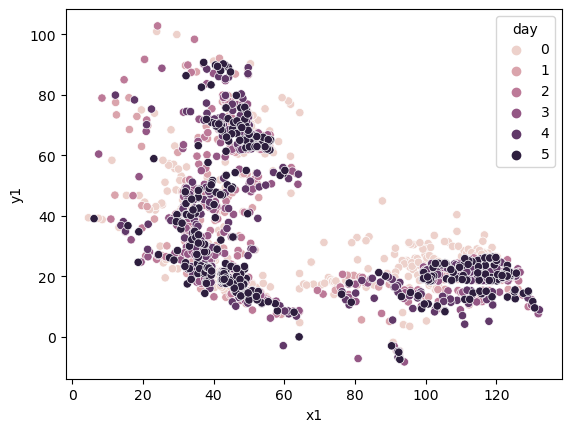

In [14]:
df = moves[moves['tag id'] == 62024]
sns.scatterplot(data=df, x='x1', y='y1', hue='day')
plt.show()

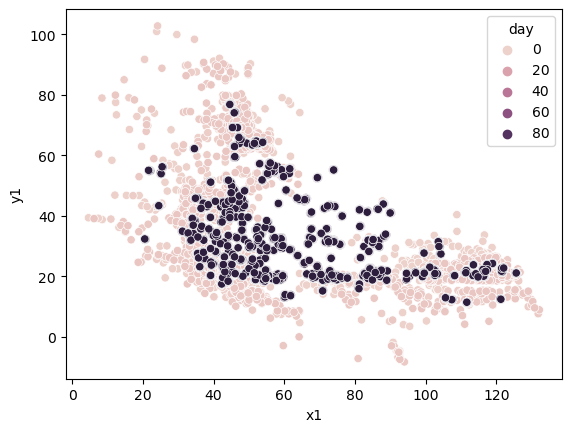

In [34]:
df = all_moves[all_moves['tag id'] == 62024]
sns.scatterplot(data=df, x='x1', y='y1', hue='day')
plt.show()

In [36]:
all_moves.to_excel('All Moves.xlsx')

ValueError: This sheet is too large! Your sheet size is: 1487955, 7 Max sheet size is: 1048576, 16384

In [114]:
import pandas as pd
import numpy as np

results = []  # collect stds for all agents and days

# Group once by tag id
for agent, a_group in moves.groupby(by='tag id'):
    
    # Filter day != 16 once
    a_group = a_group[a_group['day'] != 16]

    # Group by day
    for day, d_group in a_group.groupby('day'):

        # Group by time within this day if needed
        groups = list(d_group.groupby('time'))

        # Build x1 and y1 matrices
        xs = pd.DataFrame({
            f'x1_{day}': [group['x1'].values for _, group in groups]
        }).apply(pd.Series).T  # transpose if needed

        ys = pd.DataFrame({
            f'y1_{day}': [group['y1'].values for _, group in groups]
        }).apply(pd.Series).T

        # Ensure data is aligned row-wise
        x_vals = np.array([group['x1'].values for _, group in groups])
        y_vals = np.array([group['y1'].values for _, group in groups])

        # Compute std across columns (i.e., std of each row across time)
        std_x = x_vals.std(axis=0)
        std_y = y_vals.std(axis=0)

        # Time vector for alignment
        time_vals = [group['time'].values[0] for _, group in groups]

        # Assemble final DataFrame
        #stds = pd.DataFrame({
        #    'X': std_x,
        #    'Y': std_y,
        #    'tag id': agent,
        #    'time': time_vals
        #})

        #results.append(stds)

# Combine all results into one DataFrame
final_df = pd.concat(results, ignore_index=True)

print(final_df)


ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 383 has size 3

In [94]:
groups = df[df['day'] != 16].groupby(by='day')
#for a, x in groups:


columns, data = zip(*[(f'x1_{index}', group['x1'].values) for index, group in groups])

g = pd.DataFrame(data=np.array(data).T, columns=columns)
g.std(axis=1)

0       7.616638
1       2.193940
2      30.474778
3       1.002147
4      41.580098
         ...    
562    27.701883
563    32.146990
564    17.673953
565     1.699129
566    25.512047
Length: 567, dtype: float64

In [79]:
groups.get_group(18)

,tag id,time,color,type,x1,y1,day
43459,57586,2024-07-18 06:25:37,yellow,nurse desk,50.250788,11.626787,18
43490,57586,2024-07-18 06:25:43,yellow,nurse desk,47.560511,15.605192,18
43528,57586,2024-07-18 06:25:46,yellow,nurse desk,42.422307,20.041188,18
43620,57586,2024-07-18 06:26:08,yellow,nurse desk,42.419122,19.329993,18
43642,57586,2024-07-18 06:26:31,yellow,nurse desk,118.980933,25.993381,18
...,...,...,...,...,...,...,...
58709,57586,2024-07-18 13:37:37,yellow,nurse desk,48.746416,15.549051,18
58722,57586,2024-07-18 13:38:40,yellow,nurse desk,98.146930,13.195222,18
58731,57586,2024-07-18 13:39:22,yellow,nurse desk,65.078628,15.205595,18
58746,57586,2024-07-18 13:40:26,yellow,nurse desk,33.825858,33.482327,18


In [ ]:
scenarios = pd.read_csv("scenarios.csv", sep=';', index_col='id')
# scenarios['CleaningOption'] = scenarios['CleaningOption'].where(scenarios['CleaningOption'] == 10000000, 'never')
scenarios['CleaningOption'] = scenarios['CleaningOption'].map({
    4: '4h',
    6: '6h',
    10000000: 'never'
})

scenarios['ContactRate'] = scenarios['ContactRate'].map({
    3: '3-per-hour',
    5: '5-per-hour',
    10: '10-per-hour'
})

scenarios['HandOption'] = np.where(scenarios['HandOption'] == 0, True, False)
scenarios

In [34]:
df = pd.read_csv("spread overtime.csv", sep=';')
df = df.iloc[: , :649]
df.rename(columns={name: name.split(".")[0] for name in df.columns}, inplace=True)
df.to_csv("Simulation Outputs.csv", sep=';', index=False)
df = pd.read_csv("Simulation Outputs.csv", header=[0, 1], sep=';')
df = df.set_index(('Unnamed: 0', 'hour'))
df.index.name = 'Hour'
infected = df[df.columns[::2]]
infected.columns = list(zip(*infected.columns))[0]
infected.index = infected.index / 24
infected.index.name = 'Day'
infected

C:\Users\mohamed.abourraja\AppData\Local\Temp\ipykernel_3460\1973640133.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,2

,1,2,3,4,5,6,7,8,9,10,...,315,316,317,318,319,320,321,322,323,324
Day,,,,,,,,,,,,,,,,,,,,,
0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.041667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.083333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.125000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91.833333,1.0,2.0,1.0,3.0,1.0,3.0,1.0,2.0,3.0,1.0,...,3.0,1.0,1.0,5.0,1.0,5.0,4.0,5.0,1.0,5.0
91.875000,1.0,2.0,1.0,3.0,1.0,3.0,1.0,2.0,3.0,1.0,...,3.0,1.0,1.0,5.0,1.0,5.0,4.0,5.0,1.0,5.0
91.916667,1.0,3.0,1.0,3.0,1.0,3.0,1.0,2.0,4.0,1.0,...,3.0,1.0,1.0,5.0,1.0,5.0,4.0,5.0,1.0,5.0


In [35]:
masktypes = scenarios['MaskType'].unique()
cleaning = scenarios['CleaningOption'].unique()
hand = scenarios['HandOption'].unique()
conactrate = scenarios['ContactRate'].unique()
sickAtT0 = scenarios['SickAtT0'].unique()
scenarios

,MaskType,PeopleWithMask,SickAtT0,CleaningOption,HandOption,ContactRate
id,,,,,,
1,NO_MASK,10,1,4h,True,3-per-hour
2,NO_MASK,10,1,6h,True,3-per-hour
3,NO_MASK,10,1,never,True,3-per-hour
4,NO_MASK,10,1,4h,True,5-per-hour
5,NO_MASK,10,1,6h,True,5-per-hour
...,...,...,...,...,...,...
320,RESPIRATOR_MASK,10,6,6h,False,5-per-hour
321,RESPIRATOR_MASK,10,6,never,False,5-per-hour
322,RESPIRATOR_MASK,10,6,4h,False,10-per-hour


In [36]:
colors = {
    "NO_MASK": ["mistyrose", "lightcoral", "indianred", "salmon", "firebrick", "darkred"],
    "CLOTH_MASK": ["honeydew", "lightgreen", "mediumseagreen", "limegreen", "forestgreen", "darkgreen"],
    "SURGICAL_MASK": ["peachpuff", "moccasin", "sandybrown", "darkorange", "orange", "orangered"],
    "RESPIRATOR_MASK": ["lightblue", "lightskyblue", "deepskyblue", "dodgerblue", "royalblue", "navy"]
}

Text(0.5, 1.0, '# of Infections Over Time')

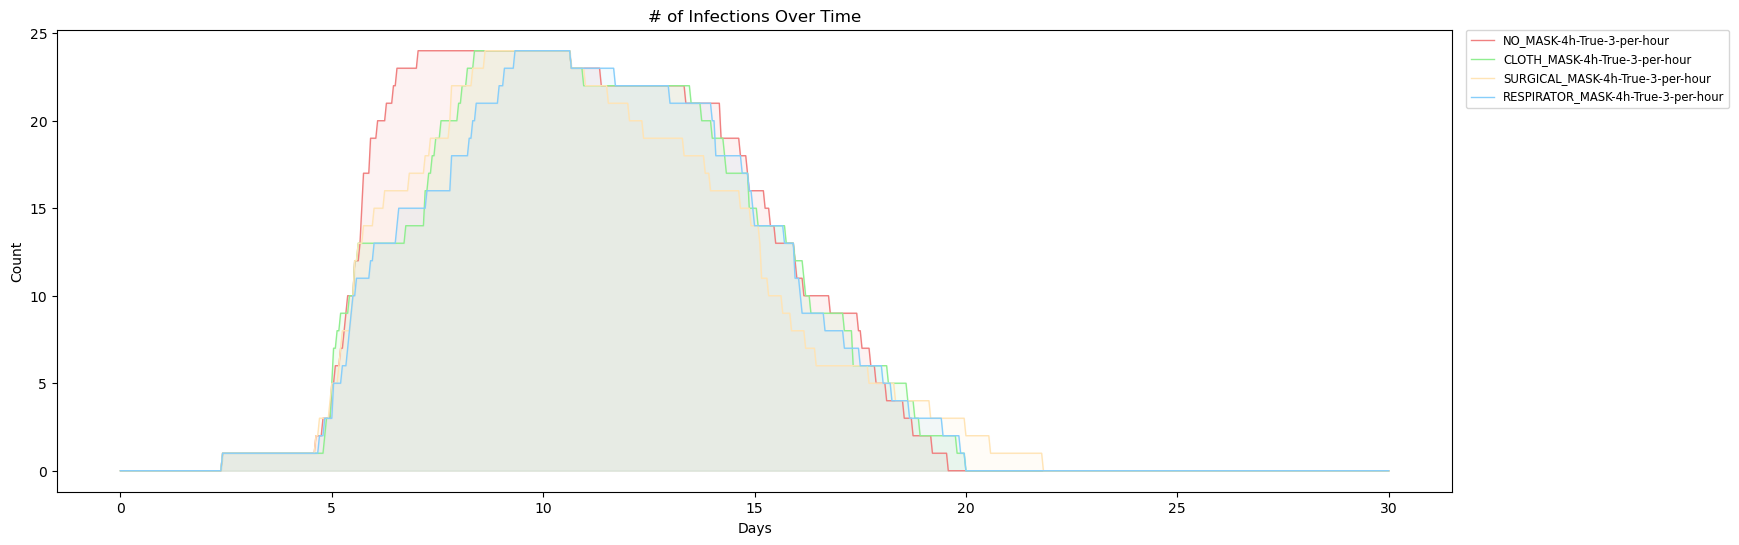

In [37]:
plt.figure(figsize=(18, 6)) 

for m in masktypes:
    for c in cleaning[:1]:
        for h in hand[:1]:
            for r in conactrate[:1]:
                for s in sickAtT0[:1]:
                    mask = (scenarios['MaskType'] == m) & (scenarios['CleaningOption'] == c) & \
                    (scenarios['HandOption'] == h) & (scenarios['SickAtT0'] == s) & ((scenarios['ContactRate'] == r))
                    col = str(scenarios[mask].index[0])
                    plt.plot(infected.index[:721], infected.loc[infected.index[:721], col], 
                             lw='1',
                             c=colors[m][1],
                             label=f'{m}-{c}-{h}-{r}')
                    
                    plt.fill_between(infected.index[:721], infected.loc[infected.index[:721], col], 
                                     color=colors[m][1], alpha=0.10)

plt.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize='small'
)

plt.xlabel('Days')
plt.ylabel('Count')
plt.title('# of Infections Over Time')

Text(0.5, 1.0, 'Impact of Mask and Device Cleaning Policies on Infection Spread (Average Infected Workers)')

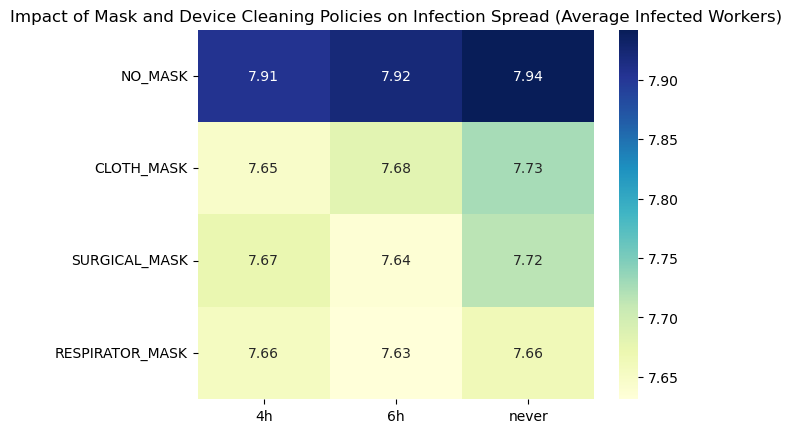

In [38]:
values = []
for m in masktypes:
    v = []
    for c in cleaning:
        mask = (scenarios['MaskType'] == m) & (scenarios['CleaningOption'] == c)
        cols = list(map(str, scenarios[mask].index))
        v.append(infected[cols].mean().mean())
    values.append(v)
    
df = pd.DataFrame(data=values, index=masktypes, columns=cleaning)
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Impact of Mask and Device Cleaning Policies on Infection Spread (Average Infected Workers)')

Text(0.5, 1.0, 'Impact of Mask and Hand Cleaning Policies on Infection Spread (Average Infected Workers)')

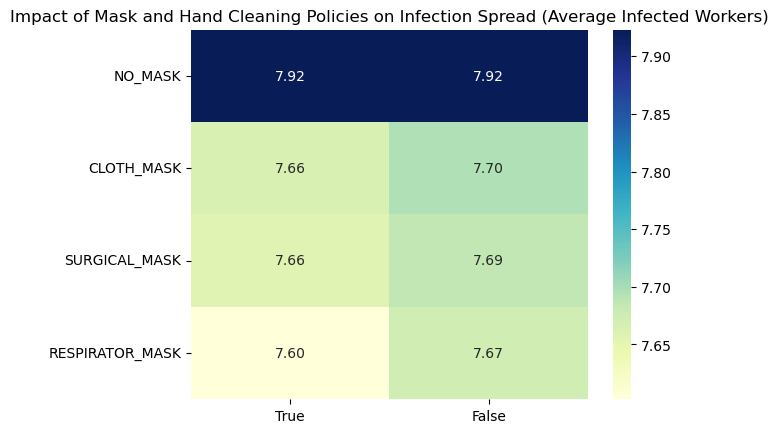

In [39]:
values = []
for m in masktypes:
    v = []
    for h in hand:
        mask = (scenarios['MaskType'] == m) & (scenarios['HandOption'] == h)
        cols = list(map(str, scenarios[mask].index))
        v.append(infected[cols].mean().mean())
    values.append(v)
    
df = pd.DataFrame(data=values, index=masktypes, columns=hand)
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Impact of Mask and Hand Cleaning Policies on Infection Spread (Average Infected Workers)')

Text(0.5, 1.0, 'Impact of Device and Hand Cleaning Policies on Infection Spread (Average Infected Workers)')

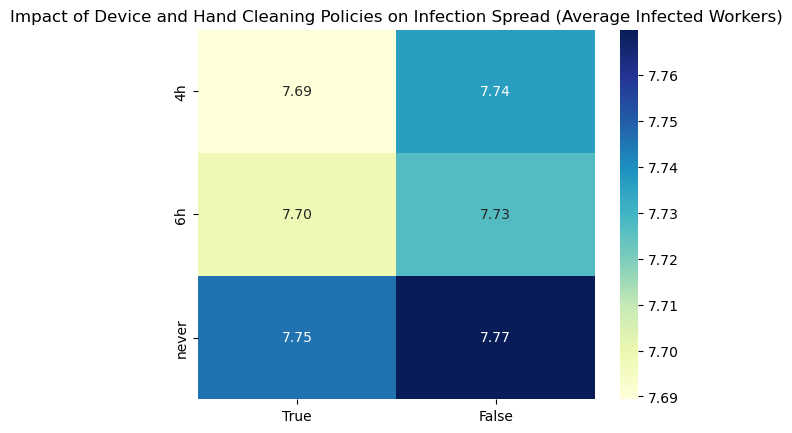

In [40]:
values = []
for c in cleaning:
    v = []
    for h in hand:
        mask = (scenarios['CleaningOption'] == c) & (scenarios['HandOption'] == h)
        cols = list(map(str, scenarios[mask].index))
        v.append(infected[cols].mean().mean())
    values.append(v)
    
df = pd.DataFrame(data=values, index=cleaning, columns=hand)
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Impact of Device and Hand Cleaning Policies on Infection Spread (Average Infected Workers)')

In [44]:
df = pd.read_csv("spread overtime.csv", sep=';')
df = df.iloc[: , :649]
df.rename(columns={name: name.split(".")[0] for name in df.columns}, inplace=True)
df.to_csv("Simulation Outputs.csv", sep=';', index=False)
df = pd.read_csv("Simulation Outputs.csv", header=[0, 1], sep=';')
df = df.set_index(('Unnamed: 0', 'hour'))
df.index.name = 'Hour'
contaminated = df[df.columns[1::2]]
contaminated.columns = list(zip(*infected.columns))[0]
contaminated.index = infected.index / 24
contaminated.index.name = 'Day'
contaminated

C:\Users\mohamed.abourraja\AppData\Local\Temp\ipykernel_3460\210207372.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,25

,1,2,3,4,5,6,7,8,9,1,...,3,3,3,3,3,3,3,3,3,3
Day,,,,,,,,,,,,,,,,,,,,,
0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.001736,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.003472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.005208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.006944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3.826389,0.0,0.0,9.0,2.0,1.0,9.0,2.0,6.0,9.0,0.0,...,9.0,0.0,0.0,9.0,1.0,3.0,9.0,5.0,1.0,9.0
3.828125,0.0,0.0,9.0,1.0,1.0,9.0,1.0,6.0,9.0,0.0,...,9.0,0.0,0.0,9.0,1.0,2.0,9.0,4.0,2.0,9.0
3.829861,0.0,0.0,9.0,1.0,1.0,9.0,1.0,3.0,9.0,0.0,...,9.0,0.0,0.0,9.0,2.0,5.0,9.0,4.0,2.0,9.0


In [50]:
reminder = 1501 % 15
reminder
for i in range(1533):
    print(i % 11)

0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5